In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2500

data = {
    "customer_id": range(1, n+1),
    "age": np.random.randint(18, 65, n),
    "gender": np.random.choice(["Male","Female"], n),
    "city": np.random.choice(["Hyderabad","Bangalore","Mumbai","Delhi","Chennai"], n),
    "annual_income": np.random.randint(20000,150000,n),
    "spending_score": np.random.randint(1,101,n),
    "membership_years": np.random.randint(1,10,n),
    "total_orders": np.random.randint(1,50,n),
    "avg_order_value": np.random.randint(200,5000,n),
    "last_purchase_days": np.random.randint(1,365,n),
    "preferred_category": np.random.choice(
        ["Electronics","Fashion","Home","Sports","Beauty"], n),
    "churn": np.random.choice([0,1], n, p=[0.75,0.25])
}

df = pd.DataFrame(data)

df.to_csv("ecommerce_data.csv", index=False)

df.head()

,customer_id,age,gender,city,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,preferred_category,churn
0,1,56,Female,Mumbai,93805,27,9,20,2040,363,Home,0
1,2,46,Male,Hyderabad,88367,74,4,22,1050,109,Beauty,0
2,3,32,Male,Bangalore,129906,63,2,47,2171,309,Sports,1
3,4,60,Female,Chennai,137409,68,4,23,1391,52,Electronics,0
4,5,25,Female,Hyderabad,97355,19,6,41,4120,1,Home,0


In [ ]:
df.shape
df.head()
df.tail()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   customer_id         2500 non-null   int64
 1   age                 2500 non-null   int32
 2   gender              2500 non-null   str  
 3   city                2500 non-null   str  
 4   annual_income       2500 non-null   int32
 5   spending_score      2500 non-null   int32
 6   membership_years    2500 non-null   int32
 7   total_orders        2500 non-null   int32
 8   avg_order_value     2500 non-null   int32
 9   last_purchase_days  2500 non-null   int32
 10  preferred_category  2500 non-null   str  
 11  churn               2500 non-null   int64
dtypes: int32(7), int64(2), str(3)
memory usage: 166.1 KB


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

num_cols, cat_cols

C:\Users\gunav\AppData\Local\Temp\ipykernel_15412\1467836123.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


(Index(['customer_id', 'age', 'annual_income', 'spending_score',
        'membership_years', 'total_orders', 'avg_order_value',
        'last_purchase_days', 'churn'],
       dtype='str'),
 Index(['gender', 'city', 'preferred_category'], dtype='str'))

In [ ]:
df.describe()

,customer_id,age,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,churn
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000
mean,1250.50000,41.129600,85184.390800,51.439600,5.028800,25.01000,2545.778000,182.553600,0.249200
std,721.83216,13.558464,37613.961586,28.657866,2.550328,13.90554,1366.150566,103.372131,0.432636
min,1.00000,18.000000,20028.000000,1.000000,1.000000,1.00000,200.000000,1.000000,0.000000
25%,625.75000,29.000000,52328.250000,26.750000,3.000000,14.00000,1393.250000,92.000000,0.000000
50%,1250.50000,42.000000,85805.500000,53.000000,5.000000,25.00000,2497.000000,183.000000,0.000000
75%,1875.25000,53.000000,118272.500000,76.000000,7.000000,37.00000,3687.750000,270.000000,0.000000
max,2500.00000,64.000000,149949.000000,100.000000,9.000000,49.00000,4999.000000,364.000000,1.000000


In [ ]:
df.skew(numeric_only=True)

customer_id           0.000000
age                  -0.029865
annual_income        -0.020058
spending_score       -0.057689
membership_years     -0.022463
total_orders          0.010749
avg_order_value       0.058659
last_purchase_days    0.014397
churn                 1.160331
dtype: float64

In [ ]:
for col in cat_cols:
    print(col, df[col].unique())

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
city <StringArray>
['Mumbai', 'Hyderabad', 'Bangalore', 'Chennai', 'Delhi']
Length: 5, dtype: str
preferred_category <StringArray>
['Home', 'Beauty', 'Sports', 'Electronics', 'Fashion']
Length: 5, dtype: str


In [ ]:
df.isnull().sum()

customer_id           0
age                   0
gender                0
city                  0
annual_income         0
spending_score        0
membership_years      0
total_orders          0
avg_order_value       0
last_purchase_days    0
preferred_category    0
churn                 0
dtype: int64

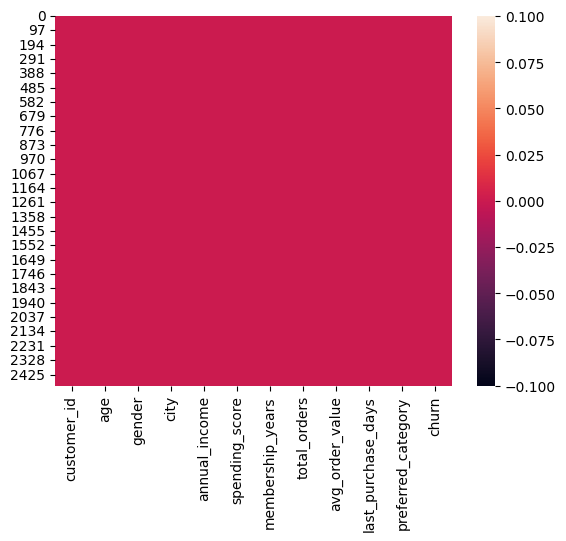

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull())
plt.show()

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,customer_id,age,gender,city,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,preferred_category,churn
0,1,56,Female,Mumbai,93805,27,9,20,2040,363,Home,0
1,2,46,Male,Hyderabad,88367,74,4,22,1050,109,Beauty,0
2,3,32,Male,Bangalore,129906,63,2,47,2171,309,Sports,1
3,4,60,Female,Chennai,137409,68,4,23,1391,52,Electronics,0
4,5,25,Female,Hyderabad,97355,19,6,41,4120,1,Home,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,21,Male,Mumbai,35762,35,4,18,4399,115,Fashion,0
2496,2497,62,Male,Mumbai,137798,11,7,29,2390,39,Sports,0
2497,2498,29,Female,Delhi,136854,61,2,25,404,217,Electronics,0
2498,2499,49,Female,Bangalore,126830,44,8,13,4029,210,Home,0


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

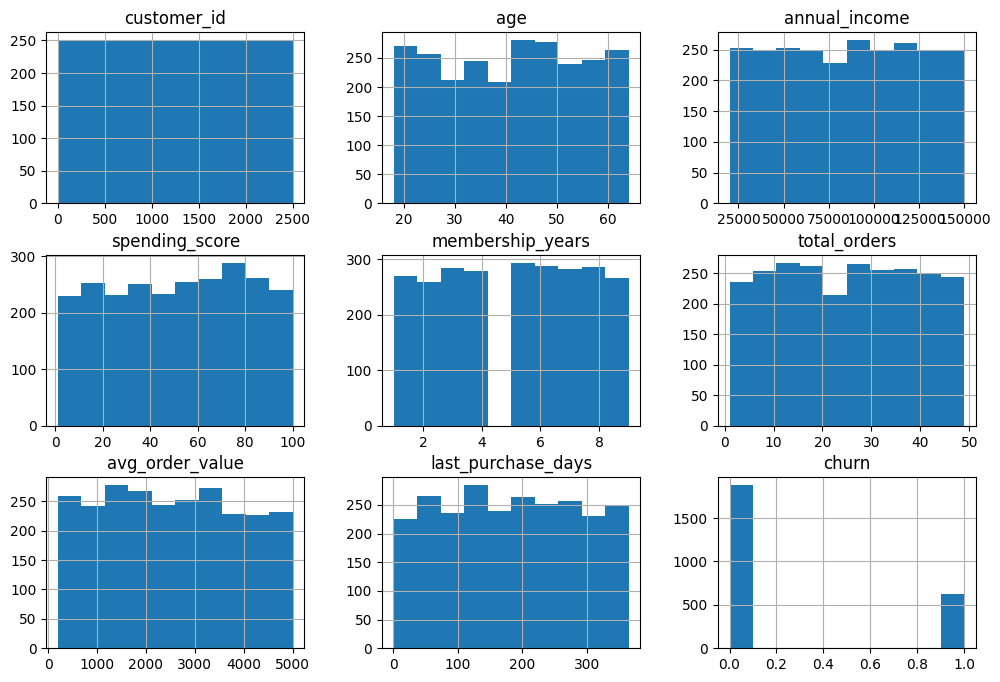

In [ ]:
df.hist(figsize=(12,8))
plt.show()

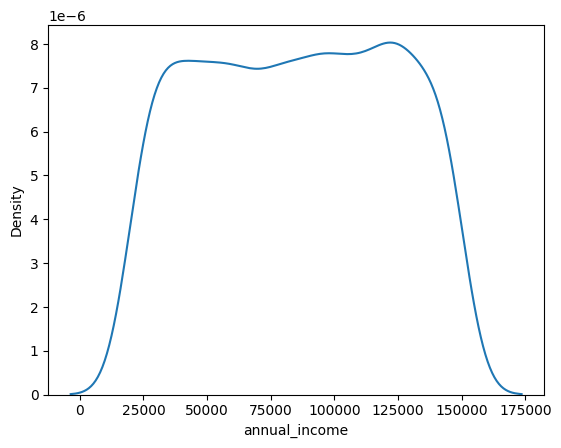

In [ ]:
sns.kdeplot(df['annual_income'])
plt.show()

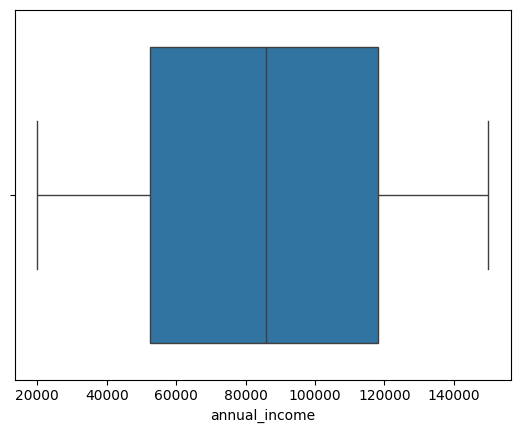

In [ ]:
sns.boxplot(x=df['annual_income'])
plt.show()

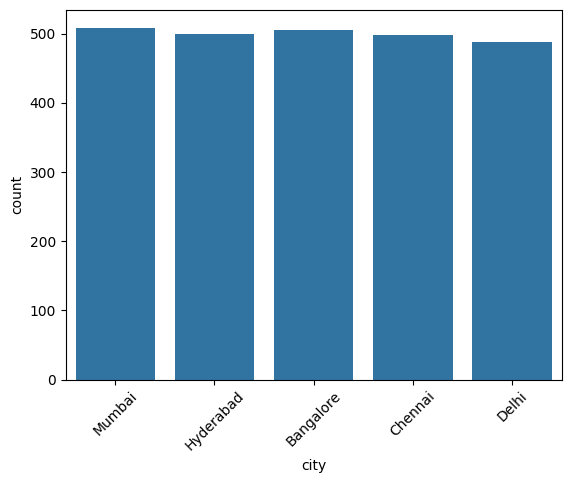

In [ ]:
sns.countplot(x='city', data=df)
plt.xticks(rotation=45)
plt.show()

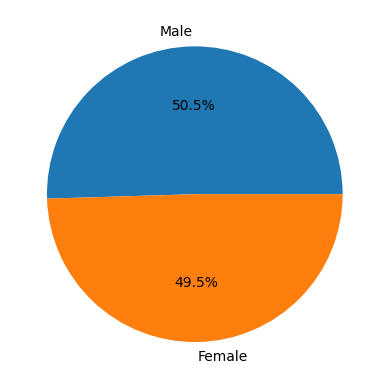

In [ ]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

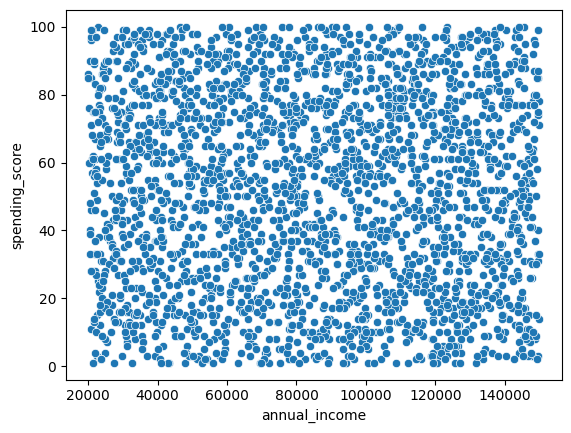

In [ ]:
sns.scatterplot(x='annual_income', y='spending_score', data=df)
plt.show()

In [ ]:
df.corr(numeric_only=True)

,customer_id,age,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,churn
customer_id,1.000000,-0.011229,0.001852,0.034947,-0.019368,-0.015889,-0.012606,0.013931,-0.005480
age,-0.011229,1.000000,-0.008035,-0.000276,-0.001138,0.021162,-0.025207,0.018090,-0.026383
annual_income,0.001852,-0.008035,1.000000,-0.021408,-0.016562,-0.002696,-0.008592,-0.009856,0.017335
spending_score,0.034947,-0.000276,-0.021408,1.000000,0.007848,-0.023764,-0.026125,-0.009227,-0.012874
membership_years,-0.019368,-0.001138,-0.016562,0.007848,1.000000,-0.030305,-0.000097,-0.031272,0.029397
total_orders,-0.015889,0.021162,-0.002696,-0.023764,-0.030305,1.000000,0.008301,-0.006583,-0.032009
avg_order_value,-0.012606,-0.025207,-0.008592,-0.026125,-0.000097,0.008301,1.000000,-0.005733,0.023709
last_purchase_days,0.013931,0.018090,-0.009856,-0.009227,-0.031272,-0.006583,-0.005733,1.000000,0.001540
churn,-0.005480,-0.026383,0.017335,-0.012874,0.029397,-0.032009,0.023709,0.001540,1.000000


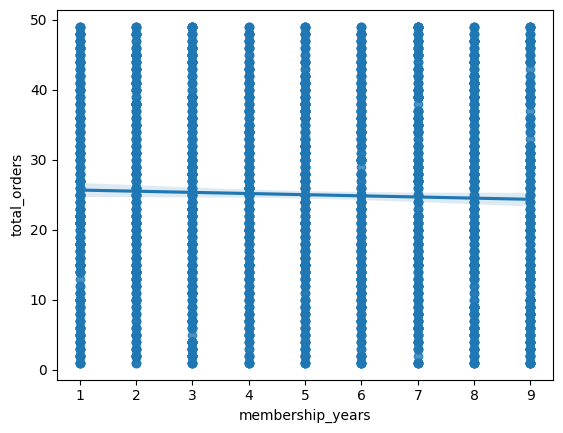

In [ ]:
sns.regplot(x='membership_years', y='total_orders', data=df)
plt.show()

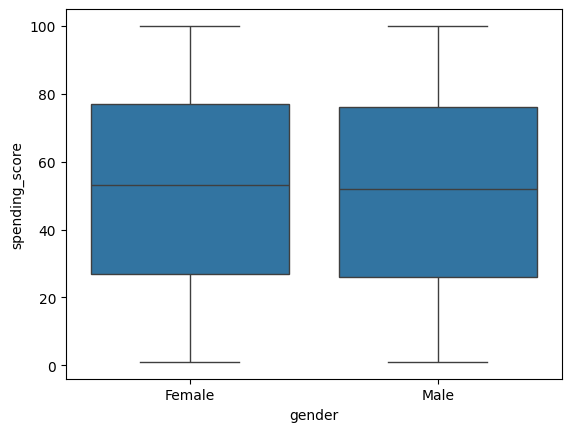

In [ ]:
sns.boxplot(x='gender', y='spending_score', data=df)
plt.show()

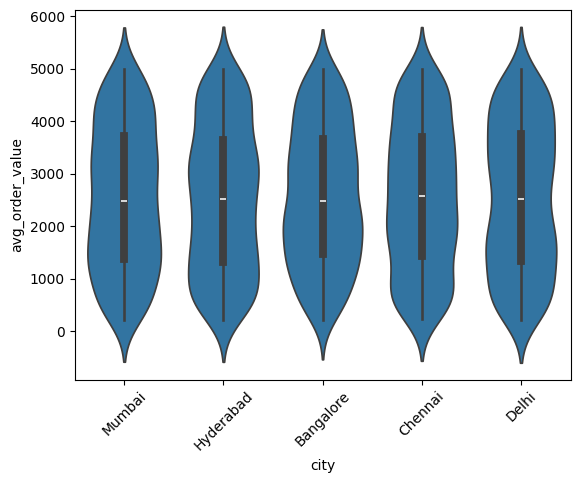

In [ ]:
sns.violinplot(x='city', y='avg_order_value', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
pd.crosstab(df['preferred_category'], df['churn'])

churn,0,1
preferred_category,,
Beauty,346,108
Electronics,380,117
Fashion,412,137
Home,361,129
Sports,378,132


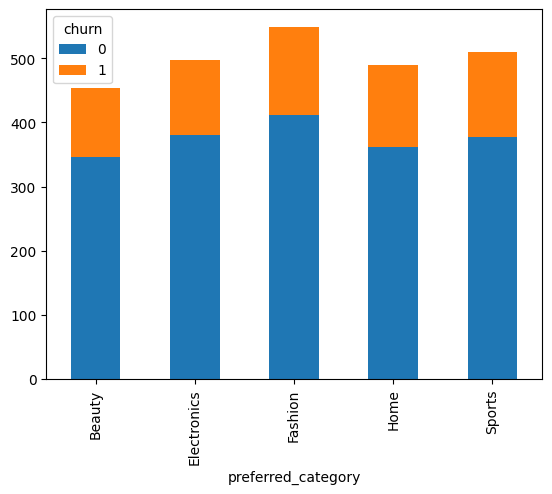

In [ ]:
pd.crosstab(df['preferred_category'], df['churn']).plot(kind='bar', stacked=True)
plt.show()

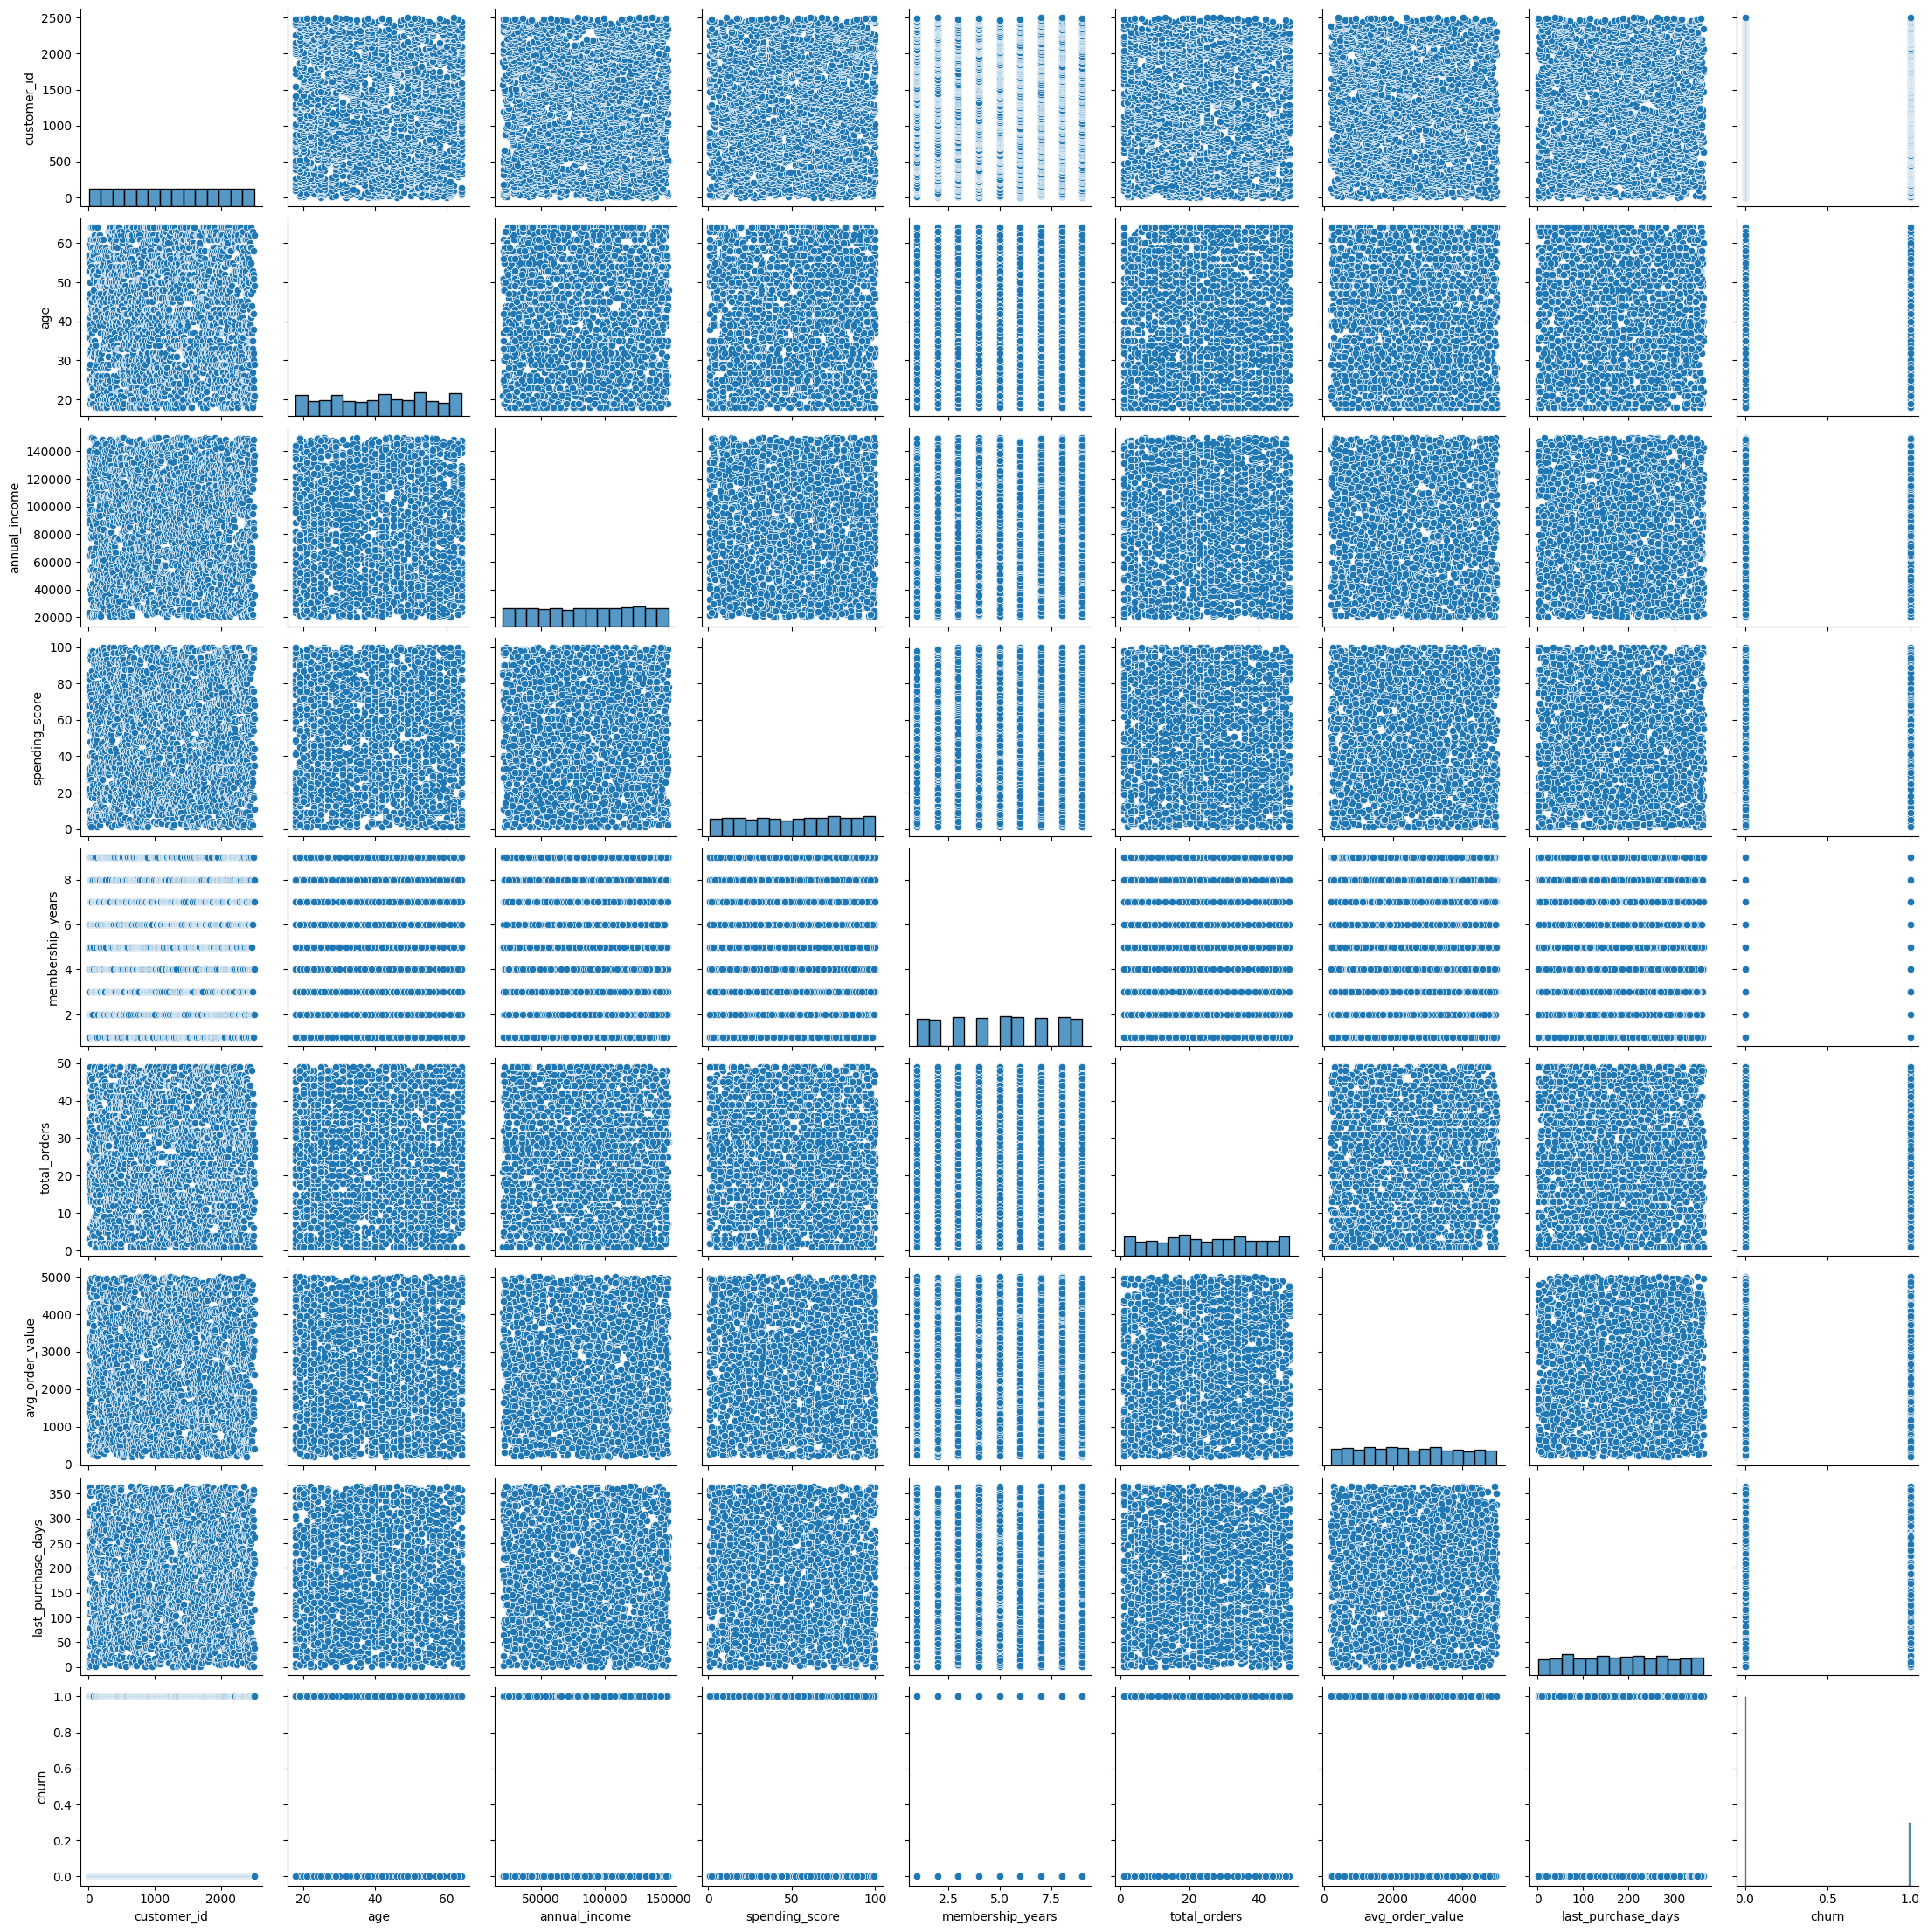

In [ ]:
sns.pairplot(df)
plt.show()

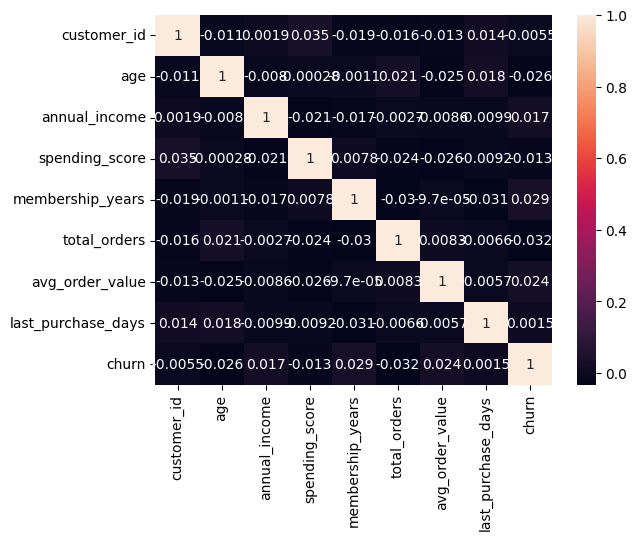

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
df.groupby('city')['avg_order_value'].mean()

city
Bangalore    2568.699605
Chennai      2557.008032
Delhi        2533.940574
Hyderabad    2528.907816
Mumbai       2539.891945
Name: avg_order_value, dtype: float64

In [ ]:
pd.pivot_table(df,
               values='avg_order_value',
               index='city',
               columns='gender')

gender,Female,Male
city,,
Bangalore,2550.527344,2587.308000
Chennai,2451.911765,2653.211538
Delhi,2574.047809,2491.464135
Hyderabad,2622.336134,2443.712644
Mumbai,2601.882353,2477.657480


In [ ]:
Q1 = df['annual_income'].quantile(0.25)
Q3 = df['annual_income'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['annual_income'] < Q1-1.5*IQR) |
              (df['annual_income'] > Q3+1.5*IQR)]

outliers.head()

,customer_id,age,gender,city,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,preferred_category,churn


In [ ]:
from scipy.stats import zscore

df['z_score'] = zscore(df['annual_income'])
df[df['z_score']>3]

,customer_id,age,gender,city,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,preferred_category,churn,z_score


In [ ]:
df['CLV'] = df['total_orders'] * df['avg_order_value']

In [ ]:
df['income_group'] = pd.qcut(df['annual_income'],3,
                             labels=['Low','Medium','High'])

In [ ]:
df['order_frequency'] = df['total_orders'] / df['membership_years']

In [ ]:
df.sort_values('CLV', ascending=False).head(10)

,customer_id,age,gender,city,annual_income,spending_score,membership_years,total_orders,avg_order_value,last_purchase_days,preferred_category,churn,z_score,CLV,income_group,order_frequency
1866,1867,58,Male,Mumbai,31560,89,5,49,4759,36,Electronics,0,-1.425936,233191,Low,9.800000
1951,1952,21,Male,Bangalore,39613,63,3,49,4748,354,Beauty,0,-1.211798,232652,Low,16.333333
332,333,34,Female,Delhi,80101,53,9,49,4727,280,Beauty,1,-0.135173,231623,Medium,5.444444
574,575,36,Female,Mumbai,39423,13,9,47,4881,335,Home,0,-1.216850,229407,Low,5.222222
1761,1762,31,Male,Bangalore,58506,72,5,49,4667,58,Fashion,0,-0.709410,228683,Low,9.800000
1513,1514,59,Male,Chennai,64328,57,3,49,4659,69,Electronics,0,-0.554596,228291,Medium,16.333333
890,891,64,Male,Chennai,27857,94,3,49,4540,7,Fashion,1,-1.524404,222460,Low,16.333333
1709,1710,46,Male,Hyderabad,125586,4,3,49,4537,8,Fashion,0,1.074327,222313,High,16.333333
1404,1405,60,Male,Delhi,83884,6,3,49,4515,282,Fashion,0,-0.034579,221235,Medium,16.333333
73,74,31,Male,Chennai,23240,38,9,48,4580,284,Home,1,-1.647175,219840,Low,5.333333


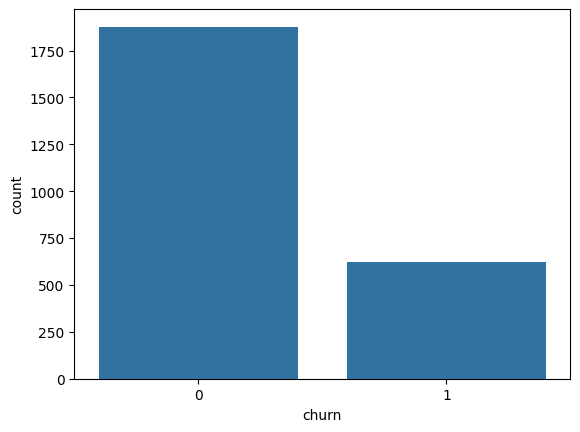

In [ ]:
sns.countplot(x='churn', data=df)
plt.show()

In [ ]:
df.groupby('preferred_category')['CLV'].sum().sort_values(ascending=False)

preferred_category
Fashion        35991949
Sports         32287039
Electronics    31019694
Home           30364622
Beauty         29905546
Name: CLV, dtype: int32

In [ ]:
df['Recency'] = df['last_purchase_days']
df['Frequency'] = df['total_orders']
df['Monetary'] = df['CLV']

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df_encoded)

In [ ]:
df_encoded.corr()['churn'].sort_values(ascending=False)

churn                             1.000000
membership_years                  0.029397
income_group_High                 0.028283
avg_order_value                   0.023709
z_score                           0.017335
annual_income                     0.017335
preferred_category_Home           0.016055
city_Hyderabad                    0.015384
preferred_category_Sports         0.011263
Recency                           0.001540
last_purchase_days                0.001540
preferred_category_Fashion        0.000423
customer_id                      -0.005480
city_Chennai                     -0.007181
gender_Male                      -0.010155
spending_score                   -0.012874
CLV                              -0.014309
Monetary                         -0.014309
city_Delhi                       -0.015421
preferred_category_Electronics   -0.015878
income_group_Medium              -0.024688
age                              -0.026383
city_Mumbai                      -0.029494
total_order